In [1]:
import os
import sys
import json
from obspy import UTCDateTime, Stream
from obspy.taup import taup_create
from matplotlib import pyplot as plt

path = '../code'
sys.path.insert(0, path)

import SeisScan as ss

# Event information

In [2]:
evt0 = UTCDateTime('2016-07-11T05:55:16.388000')
evlo = -97.6889
evla = 36.617
evdp = 3.0
mag = 2.5

# Earth model

In [3]:
#--- database directory
model_name = 'okl'
model_file = f'{model_name}.tvel'

taup_create.build_taup_model(model_file, verbose=False)

# Subnetworks

In [4]:
#--- subnetworks file
rs_file = 'rs_list.json'

rs_list = json.load(open(rs_file, 'r'))

# Prepare station list

In [5]:
stations = []

for rs in rs_list:
    reference = rs['reference']
    secondaries = rs['secondaries']
    
    stations.append(reference)
    stations += secondaries
    

# Read data

In [6]:
db_dir = '../data'

starttime = evt0 - 10
endtime = starttime + 60

network = 'YW'
stationString = ','.join(stations)
location = ''
channel = 'DP?'

inv = ss.get_inv_from_db(db_dir, network, stationString, location, channel, starttime, endtime)
st_main = ss.read_sds(db_dir, network, stationString, location, channel, starttime, endtime)

# Pre-process

In [7]:
#--- take a copy of the waveform
st = st_main.copy()

#--- detrend the data
st.detrend(type='linear')

#--- remove instrument response
pre_filt = [0.1, 0.2, 200.0, 250.0]   # Hz
st.remove_response(output='VEL', pre_filt=pre_filt);

#--- rotation from 'Z12' to 'ZNE
st.rotate('->ZNE', inventory=inv);

#--- filter
f1, f2 = 25.0, 75.0
st.select(component='Z').filter('bandpass', freqmin=f1, freqmax=f2);

f1, f2 = 10.0, 30.0
st.select(component='N').filter('bandpass', freqmin=f1, freqmax=f2);
st.select(component='E').filter('bandpass', freqmin=f1, freqmax=f2);

# Compute local similarity

In [8]:
components = ['Z', 'N', 'E']
w = 0.75 # window length in seconds
dt = 0.05 # stride in seconds
max_lag = 0.1 # maximum lag in seconds

st_r = Stream()
st_s = Stream()
st_pcc = Stream()
st_dpcc = Stream()
st_ls = Stream()
st_dls = Stream()

for component in components:

    st_r_, st_s_, st_pcc_, st_dpcc_, st_ls_, st_dls_ = ss.do_ls(st, component, rs_list=rs_list, max_lag=max_lag)

    st_r += st_r_
    st_s += st_s_
    st_pcc += st_pcc_
    st_dpcc += st_dpcc_
    st_ls += st_ls_
    st_dls += st_dls_

# Plot record section of local similarity

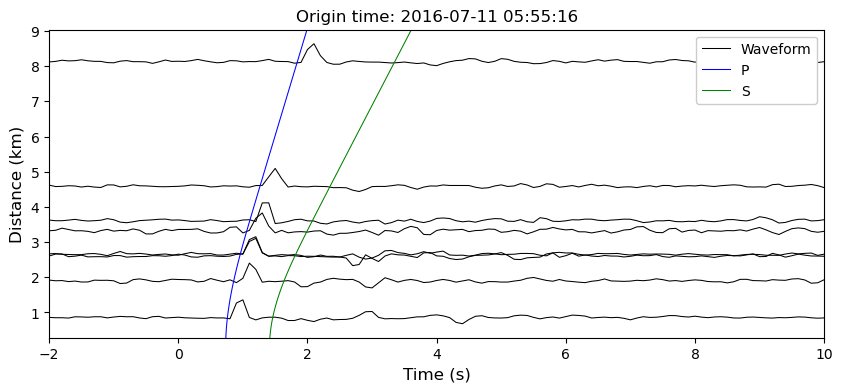

In [11]:
channel = 'DPZ'   # one of DPZ, DPN, DPE

plt.close()
ss.prs(st_dls.select(channel=channel), evt0, evlo, evla, evdp, model_name=model_name, xmin=-2, xmax=10, width=10, height=4)